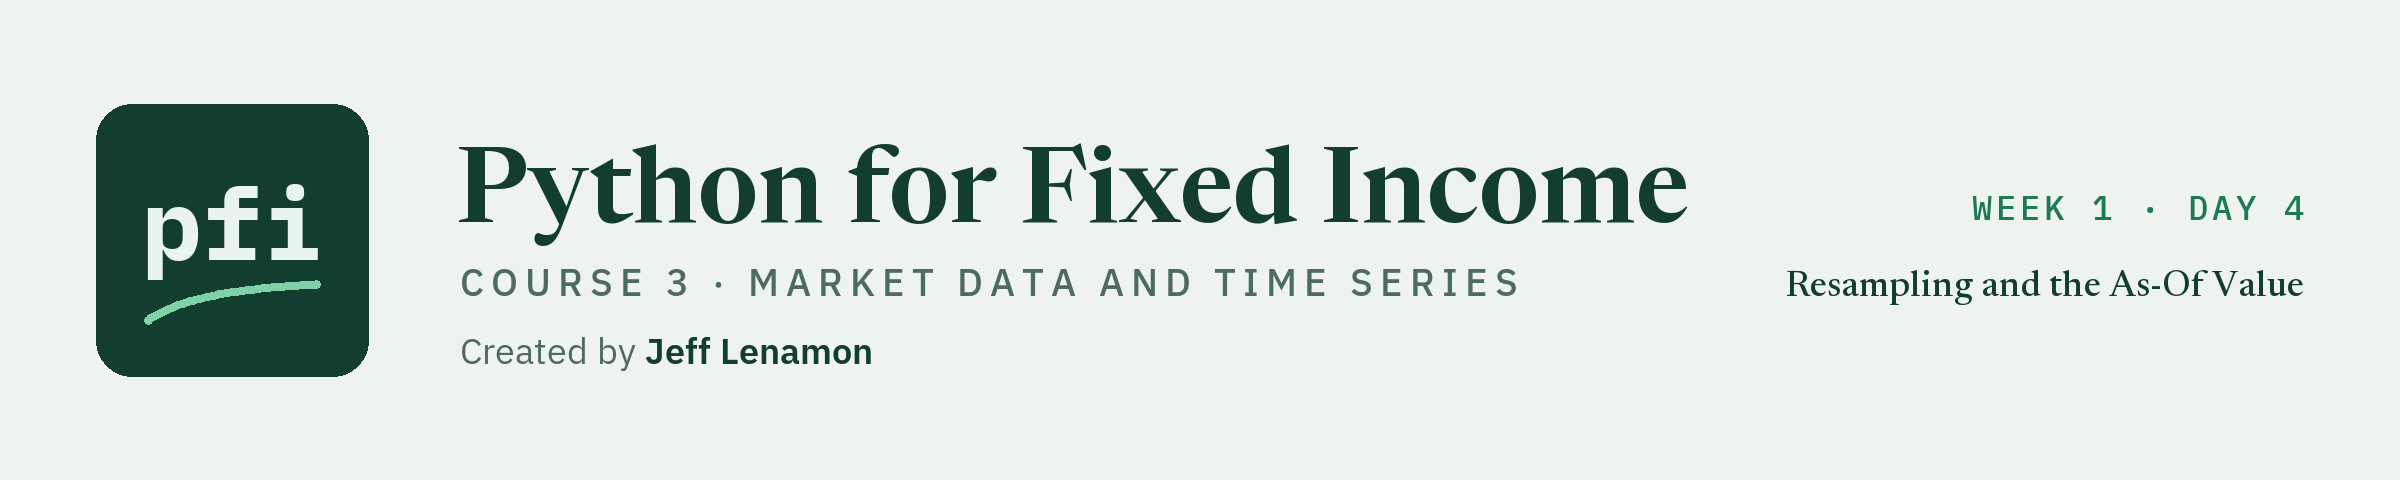

# Resampling and the As-Of Value

Week 1, Day 4. A weekly or monthly series is one observation chosen from each period. Today: which one, how to label it with the date it really comes from, what a calendar grid does to days with no row, and the as-of value: the last observation on or before any date.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course3_market_data/week1/day4/04_resampling_and_the_as_of_value.ipynb)

Yesterday the Treasury file became its own market calendar: 126 weekdays from 2015-01-02 to 2026-10-02 have no row, and a holiday calendar does not predict which. Today puts that calendar to work, on two questions every desk report asks.

**Which number stands for a month, or a week?** A monthly report shows one 10 Yr yield for September, not 21. Course 1 made monthly rows with `resample("ME").last()` and noticed that the row was labelled 2015-01-31, a Saturday the file has no row for. That label is harmless on a chart. It is a trap in a join: look up another series on that date and there is nothing there.

**What was the value on a given date?** A trade settles on a holiday, a client asks for the level "as of" a Saturday, a report runs on Labor Day. The answer is the **as-of value**: the last observation on or before that date.

Today you will:

1. Decide which observation stands for a week or a month: the last one.
2. Compare `resample(...).last()` with `last_per_period`, a function that keeps each value's real date.
3. Look at the week of Good Friday 2025, when the file has no Friday row.
4. See what `asfreq` does instead: it builds a grid of dates and leaves a hole wherever the market had no row.
5. Write `value_as_of`, and compare it with pandas' `asof`.
6. Build the 2026 month-end table of the 10 Yr, 2s10s, and the synthetic investment grade spread.

Two functions join `marketdata.py` today, with four tests. Nothing today needs a FRED key.

Q. Set up today's work folder: the Treasury file, the synthetic spreads, day 2's FRED-format sample (its tests still run), and the start-of-day module.

In [1]:
# today's setup: modules, the course data, a fresh work folder, and the constants the live cells use
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# three packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("pytest", "pytest"), ("requests", "requests"), ("dotenv", "python-dotenv")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None
import pytest
import requests

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "treasury_par_yields.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. your own key file: in your my_bondmath folder, outside every repository. Its path is never printed.
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"

# 3. the two constants of the live cells
NO_KEY_MESSAGE = "Live cell skipped: no FRED key was found. Every other cell runs without one."
# ICE BofA and Moody's values stay off the screen unless you set this to True, on your own machine only
SHOW_LICENSED_VALUES = False

# 4. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course3_04_"))
os.chdir(work)

# 5. copy today's data files into the work folder
DATA_FILES = ["treasury_par_yields.csv", "course3_synthetic_spreads.csv", "course3_fred_format_dgs10.json"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES) or 'none'}")
print(f"pytest {pytest.__version__}, requests {requests.__version__}")

Work folder: pfi_course3_04_9wklzz3q, in your temp folder
Data files from the data folder of the course repo: treasury_par_yields.csv, course3_synthetic_spreads.csv, course3_fred_format_dgs10.json
pytest 9.1.1, requests 2.34.2


Q. Write `bondmath.py`, the reference copy of the module you finished in Course 2.

It is written into the work folder so that every notebook runs, in Colab too, whether or not you took Course 2. To use your own copy instead, run this line in a new cell after the next one:

```python
shutil.copy(Path.home() / "projects" / "my_bondmath" / "bondmath.py", work)
```

The saved outputs of this notebook always come from the reference copy.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Write `marketdata.py` and `test_marketdata.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )


import pandas as pd  # dated series, from day 2
import requests  # HTTP, from day 2

# FRED's endpoint for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
    """The query parameters for one request to FRED's series/observations endpoint.

    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
    Pure: builds a dict and sends nothing. The dict holds the key, so it is never printed.
    """
    # the three parameters every request needs
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # the optional date range
    if start is not None:
        params["observation_start"] = start
    if end is not None:
        params["observation_end"] = end
    return params


def parse_fred_observations(payload: dict, name: str) -> pd.Series:
    """Turn a FRED series/observations JSON answer into a float series.

    Units: as FRED publishes the series (percent for the Treasury and spread series).
    Convention: one value per observation, indexed by its date (a DatetimeIndex named date). FRED's
    missing marker "." becomes NaN and is kept: dropping it is a separate, visible step.
    Raises ValueError if the answer has no "observations" list.
    """
    # stop on an answer that is not a series/observations answer
    if "observations" not in payload:
        raise ValueError(f"the answer for {name} has no 'observations'; keys are {sorted(payload)}")
    observations = payload["observations"]
    # each date as a calendar date
    dates = pd.to_datetime([obs["date"] for obs in observations], format="%Y-%m-%d")
    # each value as a float; "." is FRED's mark for a day with no value, so it becomes NaN, never 0
    values = [float("nan") if obs["value"] == "." else float(obs["value"]) for obs in observations]
    series = pd.Series(values, index=dates, name=name, dtype="float64")
    series.index.name = "date"
    return series


def fred_series(series_id: str, api_key: str, start: str | None = None, end: str | None = None,
                timeout: float = 30) -> pd.Series:
    """Download one series from the FRED API: one GET with requests, then parse_fred_observations.

    Units: as FRED publishes the series. Convention: "." rows are kept as NaN, as parse_fred_observations.
    The only function in this module that uses the network.
    Errors never show the key or the URL (which holds the key):
    - it never calls response.raise_for_status(), whose message holds the full URL;
    - an answer other than HTTP 200 raises RuntimeError with the status and FRED's own error message;
    - a connection problem (requests.RequestException) raises RuntimeError naming only the exception class;
    - both are raised `from None`, so no chained traceback shows the original error and its URL.
    Raises RuntimeError if FRED answers with zero observations (FRED returns HTTP 200 with count 0 for a
    range the series does not cover).
    """
    # the request, sent once; the parameters (and the key) stay inside requests
    try:
        response = requests.get(FRED_URL, params=fred_params(series_id, api_key, start, end), timeout=timeout)
    except requests.RequestException as error:
        # the original message holds the URL with the key, so only the class name is kept
        raise RuntimeError(f"Request for {series_id} failed: {type(error).__name__}") from None

    # an answer other than 200: FRED puts its reason in "error_message"
    status = response.status_code
    if status != 200:
        try:
            error_message = response.json().get("error_message", "no error message")
        except ValueError:
            error_message = "the answer was not JSON"
        # FRED's messages do not echo the key; replace it anyway in case one ever does
        error_message = error_message.replace(api_key, "***")
        raise RuntimeError(f"FRED returned HTTP {status} for {series_id}: {error_message}") from None

    # parse, and stop on an empty answer
    series = parse_fred_observations(response.json(), series_id)
    if series.empty:
        raise RuntimeError(f"FRED returned no observations for {series_id} (start {start}, end {end})")
    return series


def _check_index(index: pd.Index, what: str) -> None:
    """Stop unless `index` is a DatetimeIndex with unique dates in ascending order.

    A helper for the functions below (the leading underscore marks it as not part of the module's API).
    """
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError(f"{what} must have a DatetimeIndex, not {type(index).__name__}")
    if not index.is_unique:
        raise ValueError(f"{what} has repeated dates, for example {index[index.duplicated()][0].date()}")
    if not index.is_monotonic_increasing:
        raise ValueError(f"{what} dates are not in ascending order")


def missing_weekdays(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """The weekdays from the first date to the last that have no row.

    Units: dates. Convention: a weekday is Monday to Friday; no holiday calendar is used, so the result is
    every weekday the data skipped (holidays and any other closure). Weekends are never counted.
    Raises ValueError on an index that is not unique and ascending dates.
    """
    _check_index(index, "index")
    # every Monday to Friday in the span
    weekdays = pd.bdate_range(index[0], index[-1])
    # the ones with no row
    missing = weekdays.difference(index)
    missing.name = "date"
    return missing


def align(series: dict[str, pd.Series], how: str = "inner") -> pd.DataFrame:
    """Put several dated series side by side, one column each, joined on date.

    Units: each column keeps its own units. Convention: how="inner" keeps the dates every series has;
    how="outer" keeps every date any series has and leaves NaN where a series has no row. Nothing is filled.
    Raises ValueError for any other `how`, or for a series whose index is not unique ascending dates.
    """
    # stop on a join the course does not use
    if how not in ("inner", "outer"):
        raise ValueError(f"how must be 'inner' or 'outer', not {how!r}")
    for name, values in series.items():
        _check_index(values.index, name)
    # one column per series, named by its key
    frame = pd.concat(series, axis=1, join=how)
    # an outer join can mix the order of dates, so sort them
    frame = frame.sort_index()
    frame.index.name = "date"
    return frame


def stale_runs(series: pd.Series, min_length: int = 3) -> pd.DataFrame:
    """Runs of the same value repeated on consecutive observations: a sign of a value that stopped updating.

    Units: `value` has the series' units, `length` counts observations. Convention: consecutive means
    consecutive rows, whatever the calendar gap. One row per run of at least `min_length` identical values,
    with columns start, end, length, value.
    Raises ValueError if min_length is below 2, the series has missing values (drop them first), or its index
    is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if min_length < 2:
        raise ValueError(f"min_length must be at least 2, not {min_length}")
    if series.isna().any():
        raise ValueError(f"series has {series.isna().sum()} missing values; drop them first with .dropna()")
    # a new run starts wherever the value differs from the row before
    run_id = (series != series.shift()).cumsum()
    runs = []
    for _, run in series.groupby(run_id):
        # keep runs long enough to report
        if len(run) >= min_length:
            runs.append({"start": run.index[0], "end": run.index[-1], "length": len(run), "value": run.iloc[0]})
    return pd.DataFrame(runs, columns=["start", "end", "length", "value"])

Writing marketdata.py


In [4]:
%%writefile test_marketdata.py
"""Tests for marketdata.py.

Expected values come from Excel (course3_excel_reference.csv in this folder), from the course's data files, or
from small hand examples. No test touches the network or needs a real key: the only key is the course's fake one.
Run from this folder with:  python -m pytest
"""
import pytest

import marketdata as md

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not a key
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# the demo name; never FRED_API_KEY, because get_secret checks the environment first
DEMO_NAME = "DEMO_API_KEY"


def test_get_secret_reads_environment(monkeypatch, tmp_path):
    # monkeypatch sets the variable for this test only and removes it afterwards
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=tmp_path / ".env") == FAKE_KEY


def test_get_secret_reads_env_file(monkeypatch, tmp_path):
    # no variable in the environment, so the file is used
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}={FAKE_KEY}\n", encoding="utf-8")
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_environment_wins(monkeypatch, tmp_path):
    # both places hold a value: the environment comes first
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}=value-from-the-file\n", encoding="utf-8")
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_missing_raises_without_value(monkeypatch, tmp_path):
    # the file holds a different secret; the one asked for is nowhere
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"OTHER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    with pytest.raises(RuntimeError) as caught:
        md.get_secret(DEMO_NAME, env_file=env_file)
    message = str(caught.value)
    # the message names the secret and the places looked, and holds no value and no folder
    assert DEMO_NAME in message and "environment" in message and ".env" in message
    assert FAKE_KEY not in message
    assert str(tmp_path) not in message


import json  # the FRED-format samples, from day 2
import math  # NaN checks, from day 2
import traceback  # what a printed error would show, from day 2
from pathlib import Path  # this folder, from day 2

import pandas as pd  # dated series, from day 2
import requests  # its exception classes, from day 2

# the data files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_sample(series_id: str) -> dict:
    """A FRED-format sample from this folder: Treasury values in FRED's JSON layout, no network."""
    return json.loads((HERE / f"course3_fred_format_{series_id.lower()}.json").read_text(encoding="utf-8"))


class FakeResponse:
    """A stand-in for requests.Response: a status code, a JSON body, and a URL holding the key, no network."""

    def __init__(self, status_code: int, payload: dict):
        self.status_code = status_code
        self.payload = payload
        # a real response's URL holds the key; if fred_series ever printed it, the tests below would catch it
        self.url = f"{md.FRED_URL}?series_id=DGS10&api_key={FAKE_KEY}&file_type=json"

    def json(self) -> dict:
        return self.payload


def test_params_hold_series_and_json():
    params = md.fred_params("DGS10", FAKE_KEY, start="2015-01-01")
    assert params == {"series_id": "DGS10", "api_key": FAKE_KEY, "file_type": "json",
                      "observation_start": "2015-01-01"}
    # no end date asked for, so none is sent
    assert "observation_end" not in params


def test_parse_sample_counts_and_nan():
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    # 43 weekdays from 2026-08-03 to 2026-09-30, one of them FRED's "." on Labor Day
    assert len(series) == 43
    assert series.isna().sum() == 1
    assert math.isnan(series.loc["2026-09-07"])
    assert series.loc["2026-09-30"] == 5.29
    assert series.dtype == "float64"
    assert series.index.name == "date" and series.name == "DGS10"


def test_parse_raises_without_observations():
    with pytest.raises(ValueError):
        md.parse_fred_observations({"error_code": 400, "error_message": "Bad Request."}, "DGS10")


def test_fred_series_error_hides_key(monkeypatch):
    # an HTTP 400 answer with FRED's own message for a key that is not registered
    def fake_get_400(url, params, timeout):
        return FakeResponse(400, {"error_code": 400,
                                  "error_message": "Bad Request.  The value for variable api_key is not registered."})

    monkeypatch.setattr(requests, "get", fake_get_400)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert "HTTP 400" in str(caught.value) and "not registered" in str(caught.value)
    assert FAKE_KEY not in printed and "api_key=" not in printed

    # a connection error: requests puts the full URL, key included, in its message
    def fake_get_down(url, params, timeout):
        raise requests.ConnectionError(f"Max retries exceeded with url: /fred/series/observations?series_id=DGS10"
                                       f"&api_key={FAKE_KEY}&file_type=json")

    monkeypatch.setattr(requests, "get", fake_get_down)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert str(caught.value) == "Request for DGS10 failed: ConnectionError"
    # raised from None: no chained traceback carries the original message
    assert caught.value.__cause__ is None and caught.value.__suppress_context__
    assert FAKE_KEY not in printed and "api_key=" not in printed


def test_fred_series_empty_raises(monkeypatch):
    # FRED answers a range the series does not cover with HTTP 200 and no observations
    empty = read_sample("DGS10") | {"count": 0, "observations": []}
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, empty))
    with pytest.raises(RuntimeError):
        md.fred_series("DGS10", FAKE_KEY, start="2010-01-01", end="2010-12-31")
    # the same stand-in with the sample's observations parses as the sample does
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, read_sample("DGS10")))
    pd.testing.assert_series_equal(md.fred_series("DGS10", FAKE_KEY),
                                   md.parse_fred_observations(read_sample("DGS10"), "DGS10"))


def test_missing_weekdays_hand_index():
    # Friday 2026-09-04 to Wednesday 2026-09-09, with Monday (Labor Day) and Tuesday absent
    index = pd.DatetimeIndex(["2026-09-04", "2026-09-09"])
    missing = md.missing_weekdays(index)
    # the weekend is never counted; the two weekdays are
    assert list(missing) == [pd.Timestamp("2026-09-07"), pd.Timestamp("2026-09-08")]


def test_align_inner_keeps_common_dates():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    ten = pd.Series([5.20, 5.22, 5.25], index=dates)
    spread = pd.Series([98.0, 98.4], index=dates[[0, 2]])
    inner = md.align({"10 Yr": ten, "ig_spread_bp": spread})
    assert list(inner.index) == list(dates[[0, 2]])
    assert list(inner.columns) == ["10 Yr", "ig_spread_bp"]
    # an outer join keeps every date and leaves the gap empty, never filled
    outer = md.align({"10 Yr": ten, "ig_spread_bp": spread}, how="outer")
    assert len(outer) == 3 and math.isnan(outer.loc["2026-09-04", "ig_spread_bp"])


def test_align_rejects_unknown_how():
    ten = pd.Series([5.20], index=pd.to_datetime(["2026-09-03"]))
    with pytest.raises(ValueError):
        md.align({"10 Yr": ten}, how="left")


def test_stale_runs_finds_a_run():
    dates = pd.bdate_range("2026-09-01", periods=7)
    values = pd.Series([98.1, 98.4, 98.4, 98.4, 98.4, 98.2, 98.2], index=dates)
    runs = md.stale_runs(values, min_length=3)
    # one run of four, from the second row to the fifth; the pair at the end is too short
    assert len(runs) == 1
    assert runs.loc[0, "start"] == dates[1] and runs.loc[0, "end"] == dates[4]
    assert runs.loc[0, "length"] == 4 and runs.loc[0, "value"] == 98.4

Writing test_marketdata.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath
import marketdata as md
# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)
importlib.reload(md)
# the functions defined in each module itself, not the ones it imports
def own_functions(module):
    return [name for name, obj in vars(module).items() if callable(obj) and getattr(obj, "__module__", "") == module.__name__]

print(f"bondmath (the Course 2 reference): {len(own_functions(bondmath))} functions")
print(f"marketdata functions: {own_functions(md)}")

bondmath (the Course 2 reference): 25 functions
marketdata functions: ['get_secret', 'fred_params', 'parse_fred_observations', 'fred_series', '_check_index', 'missing_weekdays', 'align', 'stale_runs']


Q. Load the Treasury file and the synthetic spreads with their dates as the index, and take the 10 Yr as a series.

In [6]:
# dates become the index; float_precision="round_trip" reads every number exactly as written in the file
treasury = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
# invented credit spreads in bp, one row per Treasury date: synthetic, not ICE, Moody's, or any index
spreads = pd.read_csv("course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")

# the running series of the day: the 10-year par yield, in percent
ten = treasury["10 Yr"]
print(f"{len(ten):,} market days, {ten.index[0].date()} to {ten.index[-1].date()}")
print(f"synthetic spreads: {len(spreads):,} rows, same dates as the Treasury file: {spreads.index.equals(treasury.index)}")

2,940 market days, 2015-01-02 to 2026-10-02
synthetic spreads: 2,940 rows, same dates as the Treasury file: True


* 2,940 market days. The spreads file has a row for every one of them and no others, which day 3's `align` would confirm.

## 4.1 Which Observation Stands for a Week or a Month

A month of daily yields can be reduced to one number in several ways. Each answers a different question:

| Choice | Answers | pandas |
| --- | --- | --- |
| First observation | Where did the month start? | `.first()` |
| Last observation | Where did the month end? | `.last()` |
| Mean | What was the average level? | `.mean()` |
| Highest, lowest | What was the range? | `.max()`, `.min()` |

When a desk says "the September level" or "the month-end 10 Yr", it means the **last** observation of the month: the close of its last market day. A weekly series works the same way, with weeks ending on Friday. This course fixes both in writing: the last observation in each calendar month (`ME`) and in each week ending Friday (`W-FRI`).

Q. Which number stands for September 2026? Compare the four choices.

In [7]:
september = ten.loc["2026-09"]

print(f"{len(september)} market days in September 2026, {september.index[0].date()} to {september.index[-1].date()}")
print(f"first: {september.iloc[0]:.2f} percent, on {september.index[0].date()}")
print(f"last:  {september.iloc[-1]:.2f} percent, on {september.index[-1].date()}")
print(f"mean:  {september.mean():.4f} percent, a number no market day printed")
print(f"high:  {september.max():.2f} percent, on {september.idxmax().date()}")

21 market days in September 2026, 2026-09-01 to 2026-09-30
first: 4.79 percent, on 2026-09-01
last:  5.29 percent, on 2026-09-30
mean:  4.9890 percent, a number no market day printed
high:  5.29 percent, on 2026-09-30


* The first, the last, and the mean are three different numbers: 4.79, 5.29, and 4.9890 percent. This month the high was on the last day, so it equals the last; in 6 of the 10 months of 2026 it does not. A table headed "September" must say which one it holds. The month-end level is the last: 5.29 percent on 2026-09-30.

Q. The last observation of a month is on the month's last **market** day. How often is that not the calendar month end?

In [8]:
# the calendar end of every complete month the file covers
calendar_ends = pd.date_range(ten.index[0], ten.index[-1], freq="ME")
# the ones the file has no row for: a weekend, or a weekday with no row
no_row = calendar_ends[~calendar_ends.isin(ten.index)]

print(f"{len(calendar_ends)} complete months; {len(no_row)} of them end on a day with no row")
print("in 2026:", ", ".join(f"{d.date()} ({d.day_name()})" for d in no_row if d.year == 2026))

141 complete months; 42 of them end on a day with no row
in 2026: 2026-01-31 (Saturday), 2026-02-28 (Saturday), 2026-05-31 (Sunday)


* 42 of 141 month ends have no row: about 30%. In 2026, January and February end on a Saturday and May on a Sunday.
* For those months the month-end level comes from an earlier day, and the question for the rest of today is **what date to write next to it**.

## 4.2 `resample(...).last()` and Its Labels, Against `last_per_period`

Course 1 made a monthly series with `resample("ME").last()`. Here it is again, on 2026.

Q. Resample the 10 Yr to month end with Course 1's line, and look at 2026.

In [9]:
# Course 1's line: group by calendar month, keep the last value of each
by_resample = ten.resample("ME").last()
by_resample.loc["2026"]

date
2026-01-31    4.26
2026-02-28    3.97
2026-03-31    4.30
2026-04-30    4.40
2026-05-31    4.45
2026-06-30    4.44
2026-07-31    4.75
2026-08-31    4.75
2026-09-30    5.29
2026-10-31    5.28
Freq: ME, Name: 10 Yr, dtype: float64

* The values are right: each is the last observation of its month. The **labels** are the calendar month ends, whatever the data holds.

Q. Which of these labels are dates the file has a row for?

In [10]:
labels_2026 = by_resample.loc["2026"].index
# isin asks, for each label, whether it is one of the file's dates
for label, in_file in zip(labels_2026, labels_2026.isin(ten.index)):
    print(f"{label.date()} {label.day_name():<9} in the file: {in_file}")

2026-01-31 Saturday  in the file: False
2026-02-28 Saturday  in the file: False
2026-03-31 Tuesday   in the file: True
2026-04-30 Thursday  in the file: True
2026-05-31 Sunday    in the file: False
2026-06-30 Tuesday   in the file: True
2026-07-31 Friday    in the file: True
2026-08-31 Monday    in the file: True
2026-09-30 Wednesday in the file: True
2026-10-31 Saturday  in the file: False


* 4 of the 10 labels are not market dates: three weekends and 2026-10-31, a date after the file ends. October's row is a part month built from the file's last two rows, and its label hides that.

Q. Why does a label matter? Look up the 2 Yr on each label, as a join on date would.

In [11]:
# reindex looks up each label in the 2 Yr series; a label with no row gets NaN
two_on_labels = treasury["2 Yr"].reindex(by_resample.index)
print(f"2 Yr found on {two_on_labels.notna().sum()} of {len(two_on_labels)} month labels")
two_on_labels.loc["2026"]

2 Yr found on 99 of 142 month labels


date
2026-01-31     NaN
2026-02-28     NaN
2026-03-31    3.79
2026-04-30    3.88
2026-05-31     NaN
2026-06-30    4.14
2026-07-31    4.28
2026-08-31    4.34
2026-09-30    4.88
2026-10-31     NaN
Freq: ME, Name: 2 Yr, dtype: float64

* The 2 Yr is missing on 43 of 142 labels, though it has a value for every month's last market day. Nothing raised an error. A month-end 2s10s built this way would quietly lose those months, or, after a careless forward fill, carry values onto days the market never had.

**The course's rule:** a weekly or monthly series is labelled by the date of the observation it holds. September 2026 is labelled 2026-09-30 because that row exists; May 2026 is labelled 2026-05-29, its last market day. Every label is then a real market date, and joins on it find what they should.

Q. Add `last_per_period` to `marketdata.py`. Read the docstring first. A small helper, `_check_series`, comes with it: it stops on missing values, because the last value of a period must be a value the market printed.

In [12]:
%%writefile -a marketdata.py


def _check_series(series: pd.Series, what: str) -> None:
    """Stop unless `series` has unique ascending dates and no missing values (a helper, not part of the API)."""
    _check_index(series.index, what)
    if series.isna().any():
        raise ValueError(f"{what} has {series.isna().sum()} missing values; drop them first with .dropna()")


def last_per_period(data: pd.Series | pd.DataFrame, freq: str) -> pd.Series | pd.DataFrame:
    """The last observation in each week or month, labelled by the date of that observation.

    Units: unchanged. Convention: freq "W-FRI" is the week ending Friday, "ME" the calendar month. Each
    period's row is the last row the data has in it, kept with its own date: September 2026 is labelled
    2026-09-30, and the week of Good Friday 2025 (no row on Friday 2025-04-18) is labelled Thursday 2025-04-17.
    pandas' resample(freq).last() labels by the period end instead. A Series must have no missing values;
    a DataFrame's rows are taken as they are, so a tenor with no value that day stays NaN.
    Raises ValueError for any other freq, or for an index that is not unique ascending dates.
    """
    # the two periods the course uses, with pandas' name for each period
    periods = {"W-FRI": "W-FRI", "ME": "M"}
    if freq not in periods:
        raise ValueError(f"freq must be 'W-FRI' or 'ME', not {freq!r}")
    if isinstance(data, pd.Series):
        _check_series(data, "data")
    else:
        _check_index(data.index, "data")
    # the period each row belongs to
    period_of_row = data.index.to_period(periods[freq])
    # the position of the last row in each period
    positions = pd.Series(range(len(data)), index=data.index).groupby(period_of_row).max()
    # those rows, with their own dates
    return data.iloc[positions.to_numpy()]

Appending to marketdata.py


* `data.index.to_period(...)` turns each date into the week or month it belongs to. pandas calls a calendar month `"M"` when it names a period and `"ME"` when it names a month **end**, so the function maps one to the other.
* `pd.Series(range(len(data)), ...).groupby(period_of_row).max()` finds the **position** of the last row in each period.
* `data.iloc[...]` takes those rows as they are, dates included. Nothing is relabelled, so the label is the real date by construction.
* A DataFrame's rows are taken whole: a tenor with no value on a period's last row stays `NaN`. The function never fills.

Q. Reload the module and take the month-end 10 Yr with `last_per_period`.

In [13]:
# the file changed, so reload before using the new function
importlib.reload(md)

month_end = md.last_per_period(ten, "ME")
month_end.loc["2026"]

date
2026-01-30    4.26
2026-02-27    3.97
2026-03-31    4.30
2026-04-30    4.40
2026-05-29    4.45
2026-06-30    4.44
2026-07-31    4.75
2026-08-31    4.75
2026-09-30    5.29
2026-10-02    5.28
Name: 10 Yr, dtype: float64

Q. Are the values the same as Course 1's, and are the labels all market dates?

In [14]:
print(f"months: {len(month_end)} here, {len(by_resample)} from resample")
print(f"the same values in every month: {(month_end.to_numpy() == by_resample.to_numpy()).all()}")
print(f"labels that differ: {(month_end.index != by_resample.index).sum()}")
print(f"every label is a market date: {month_end.index.isin(ten.index).all()}")

months: 142 here, 142 from resample
the same values in every month: True
labels that differ: 43
every label is a market date: True


* The same 142 values; 43 labels differ: the 42 month ends with no row, and October 2026.
* October is now labelled 2026-10-02, the last date in the file. The label itself says the month is not finished, which `2026-10-31` hid.

Q. The function accepts only the two periods the course uses. Ask it for quarters.

In [15]:
# "QE" is pandas' quarter end; last_per_period refuses anything but "W-FRI" and "ME"
try:
    md.last_per_period(ten, "QE")
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: freq must be 'W-FRI' or 'ME', not 'QE'


* A `ValueError` that names the two choices. A function that refuses an input it was not designed for is safer than one that guesses.

## 4.3 The Week of Good Friday 2025

Weeks end on Friday (`W-FRI`). Most weeks have a Friday row. Some do not.

Q. Show the 10 Yr for the week of Monday 2025-04-14 to Friday 2025-04-18.

In [16]:
ten.loc["2025-04-14":"2025-04-18"]

date
2025-04-14    4.38
2025-04-15    4.35
2025-04-16    4.29
2025-04-17    4.34
Name: 10 Yr, dtype: float64

* Four rows, Monday to Thursday. The file has no row on Friday 2025-04-18, Good Friday. The week's last observation is Thursday's.

Q. Make the weekly series both ways and compare the weeks around it.

In [17]:
weekly_resample = ten.resample("W-FRI").last()
weekly = md.last_per_period(ten, "W-FRI")

# the three weeks around Good Friday 2025, side by side; both have one row per week
around = weekly.loc["2025-04-11":"2025-04-25"]
pd.DataFrame({"resample label": weekly_resample.loc["2025-04-11":"2025-04-25"].index.date,
              "last_per_period label": around.index.date,
              "10 Yr": around.to_numpy()})

,resample label,last_per_period label,10 Yr
0,2025-04-11,2025-04-11,4.48
1,2025-04-18,2025-04-17,4.34
2,2025-04-25,2025-04-25,4.29


* The same value, 4.34 percent. `resample` labels the week 2025-04-18, a day with no row; `last_per_period` labels it 2025-04-17, the day the value is from.

Q. How many weeks in the file end on a day other than Friday, and which day?

In [18]:
not_friday = weekly.index[weekly.index.dayofweek != 4]
print(f"{len(weekly)} weeks; {len(not_friday)} end on a day other than Friday")
print(pd.Series(not_friday.day_name()).value_counts().to_string())
print("the first five:", ", ".join(str(d.date()) for d in not_friday[:5]))

614 weeks; 20 end on a day other than Friday
date
Thursday    20
the first five: 2015-07-02, 2015-12-24, 2015-12-31, 2016-03-24, 2016-11-10


* 20 of 614 weeks end on a Thursday, because the file has no row on that Friday. Those Fridays are among day 3's 126 weekdays with no row: 8 are Good Fridays and 12 are other Fridays. The file also has rows on some Good Fridays (2026-04-03 is one), which is why the course takes the calendar from the file and not from a rule.

## 4.4 `asfreq` Against `last`: What a Calendar Grid Does to Holidays

pandas has a second way to change frequency, `asfreq`. It looks similar and does something different:

* `resample(...).last()` and `last_per_period` ask, for each period, **what was the last observation**.
* `asfreq(...)` builds a **grid** of dates (every Friday, every month end, every business day) and asks **what was the value on exactly that date**. A grid date with no row gets `NaN`.

Q. Put the 10 Yr on a grid of Fridays.

In [19]:
grid_weekly = ten.asfreq("W-FRI")
print(f"{len(grid_weekly)} Fridays on the grid, {grid_weekly.isna().sum()} with no value")
grid_weekly.loc["2025-04-11":"2025-04-25"]

614 Fridays on the grid, 20 with no value


date
2025-04-11    4.48
2025-04-18     NaN
2025-04-25    4.29
Freq: W-FRI, Name: 10 Yr, dtype: float64

* Good Friday 2025 is on the grid, with `NaN`: the market had no row that day. 20 Fridays are empty, the same 20 weeks section 4.3 found.

Q. And a grid of month ends?

In [20]:
grid_monthly = ten.asfreq("ME")
print(f"{len(grid_monthly)} month ends on the grid, {grid_monthly.isna().sum()} with no value; the grid stops at {grid_monthly.index[-1].date()}")
grid_monthly.loc["2026"]

141 month ends on the grid, 42 with no value; the grid stops at 2026-09-30


date
2026-01-31     NaN
2026-02-28     NaN
2026-03-31    4.30
2026-04-30    4.40
2026-05-31     NaN
2026-06-30    4.44
2026-07-31    4.75
2026-08-31    4.75
2026-09-30    5.29
Freq: ME, Name: 10 Yr, dtype: float64

* 42 of 141 month ends are empty: the 42 that fall on a day with no row. January, February, and May 2026 have no month-end value at all on this grid.
* The grid stops at 2026-09-30, the last month end on or before the last date, so October 2026 is not there. `resample` and `last_per_period` both keep it.

Q. A grid of business days, Monday to Friday, is the calendar day 3 compared the file with. Are its empty dates day 3's missing weekdays?

In [21]:
grid_daily = ten.asfreq("B")
empty = grid_daily.index[grid_daily.isna()]
print(f"{len(grid_daily):,} business days on the grid, {len(empty)} with no value")
print(f"the same dates as md.missing_weekdays: {empty.equals(md.missing_weekdays(ten.index))}")

3,066 business days on the grid, 126 with no value


the same dates as md.missing_weekdays: True


* 3,066 business days, 126 empty, exactly day 3's missing weekdays.

| | `last_per_period` (and `resample(...).last()`) | `asfreq` |
| --- | --- | --- |
| Asks | the last observation in each period | the value on each grid date |
| A period whose end has no row | the last earlier row's value | `NaN` |
| A part period at the end | kept | dropped |
| Use it for | weekly and monthly levels | seeing which grid dates have no data |

`asfreq` is useful for exactly the job of the last row: it shows which dates of a regular calendar have no observation. Filling its holes (`.ffill()`) puts Thursday's value on a Friday the market was closed. That is day 3's rule again: forward fill is for display only, never before a change, a window, or a join.

## 4.5 The As-Of Value: `value_as_of`, and `asof` in pandas

A month-end level is one case of a more general question: **what was the value as of a date?** The course's definition: the last observation on or before that date. On a market day it is that day's value. On a weekend or a weekday with no row it is the previous market day's value. Before the first observation there is no answer, and the function says so instead of guessing.

Q. Add `value_as_of` to `marketdata.py`, docstring first.

In [22]:
%%writefile -a marketdata.py


def value_as_of(series: pd.Series, as_of) -> tuple[pd.Timestamp, float]:
    """The date and value of the last observation on or before `as_of`.

    Units: the value has the series' units. Convention: the as-of value; on a holiday or weekend it is
    the previous market day's value. Excel: =XLOOKUP(as_of, dates, values, , -1).
    Raises ValueError if as_of is before the first observation, the series has missing values, or its
    index is not unique ascending dates.
    """
    _check_series(series, "series")
    as_of = pd.Timestamp(as_of)
    # stop before the start: there is no value to carry
    if as_of < series.index[0]:
        raise ValueError(f"{as_of.date()} is before the first observation, {series.index[0].date()}")
    # the position of the last date on or before as_of
    position = series.index.searchsorted(as_of, side="right") - 1
    return series.index[position], float(series.iloc[position])

Appending to marketdata.py


* `series.index.searchsorted(as_of, side="right")` finds where `as_of` would go in the sorted dates, after any equal date. One less is the position of the last date on or before it.
* It returns the **date** with the value. Knowing that the value as of Monday 2026-09-07 comes from Friday 2026-09-04 is part of the answer.
* The docstring names Excel's equivalent, `XLOOKUP` with match mode -1, which the Excel section below tests.

Q. Reload, and ask for the 10 Yr as of Labor Day, Monday 2026-09-07, a weekday with no row.

In [23]:
importlib.reload(md)

as_of_date, value = md.value_as_of(ten, "2026-09-07")
print(f"10 Yr as of 2026-09-07: {value:.2f} percent, from {as_of_date.date()} ({as_of_date.day_name()})")

10 Yr as of 2026-09-07: 4.78 percent, from 2026-09-04 (Friday)


Q. As of a Saturday, and as of a market day?

In [24]:
for day in ["2026-10-03", "2026-09-30"]:
    as_of_date, value = md.value_as_of(ten, day)
    print(f"as of {day}: {value:.2f} percent, from {as_of_date.date()}")

as of 2026-10-03: 5.28 percent, from 2026-10-02
as of 2026-09-30: 5.29 percent, from 2026-09-30


* Saturday 2026-10-03 takes Friday's value, 5.28 percent. On 2026-09-30, a market day, the as-of value is that day's own.

pandas has a built-in for the value part: `Series.asof`.

Q. Compare `asof` with `value_as_of`, on Labor Day and on a date before the file starts.

In [25]:
print(f"asof on 2026-09-07: {ten.asof(pd.Timestamp('2026-09-07')):.2f} percent")
# before the first observation there is no value to carry
print(f"asof on 2014-12-31: {ten.asof(pd.Timestamp('2014-12-31'))}")

asof on 2026-09-07: 4.78 percent
asof on 2014-12-31: nan


* On Labor Day they agree. Before the start, `asof` returns `nan` and carries on: a silent hole that would show up much later, as a blank cell or a `NaN` total. `asof` also returns only the value, not the date it came from.

Q. Ask `value_as_of` for the same date.

In [26]:
try:
    md.value_as_of(ten, "2014-12-31")
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: 2014-12-31 is before the first observation, 2015-01-02


* A `ValueError` that names the date and the first observation. A check that stops beats a value that is quietly missing.

Q. One more rule from the helper. The `1.5 Month` tenor starts in 2025, so most of its column is empty. Ask for its value as of Labor Day.

In [27]:
try:
    md.value_as_of(treasury["1.5 Month"], "2026-09-07")
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: series has 2532 missing values; drop them first with .dropna()


* `_check_series` stops: 2,532 missing values. Dropping them is a visible step, in your code, never inside the function.

In [28]:
# drop the empty rows first, where a reader can see it, then ask again
as_of_date, value = md.value_as_of(treasury["1.5 Month"].dropna(), "2026-09-07")
print(f"1.5 Month as of 2026-09-07: {value:.2f} percent, from {as_of_date.date()}")

1.5 Month as of 2026-09-07: 3.83 percent, from 2026-09-04


* 3.83 percent from 2026-09-04, the same as-of date as the 10 Yr.

Q. Write today's four tests. They read the Treasury file in the work folder, so each asserts a fact about real dates.

In [29]:
%%writefile -a test_marketdata.py


def read_treasury() -> pd.DataFrame:
    """The Treasury par yield file in this folder: one row per market date, yields in percent."""
    return pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"], index_col="date")


def test_month_end_label_is_observation_date():
    ten = read_treasury()["10 Yr"]
    month_end = md.last_per_period(ten, "ME")
    assert month_end.loc["2026-09"].index[0] == pd.Timestamp("2026-09-30")
    assert month_end.loc["2026-09-30"] == 5.29
    # May 2026 ends on Sunday 31, so its label is the last market day, Friday 29
    assert pd.Timestamp("2026-05-29") in month_end.index and pd.Timestamp("2026-05-31") not in month_end.index


def test_good_friday_week_takes_thursday():
    ten = read_treasury()["10 Yr"]
    weekly = md.last_per_period(ten, "W-FRI")
    # no row on Good Friday 2025-04-18, so the week is labelled by Thursday's row
    assert pd.Timestamp("2025-04-17") in weekly.index
    assert pd.Timestamp("2025-04-18") not in weekly.index
    assert weekly.loc["2025-04-17"] == ten.loc["2025-04-17"]


def test_value_as_of_holiday_returns_previous_day():
    ten = read_treasury()["10 Yr"]
    # Labor Day 2026-09-07 has no row: the as-of value is Friday 2026-09-04's
    as_of_date, value = md.value_as_of(ten, "2026-09-07")
    assert as_of_date == pd.Timestamp("2026-09-04")
    assert value == ten.loc["2026-09-04"]


def test_value_as_of_before_start_raises():
    ten = read_treasury()["10 Yr"]
    with pytest.raises(ValueError):
        md.value_as_of(ten, "2014-12-31")

Appending to test_marketdata.py


* `test_month_end_label_is_observation_date`, `test_good_friday_week_takes_thursday`, `test_value_as_of_holiday_returns_previous_day`, `test_value_as_of_before_start_raises`.
* The first two are the labelling rule: September 2026 is 2026-09-30 at 5.29 percent, May 2026 is labelled by Friday the 29th, and the week of Good Friday 2025 by its Thursday. The last two are the as-of rule: a holiday returns the previous market day, and a date before the start raises.

Q. Run the tests.

In [30]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.................                                                        [100%]
17 passed in 0.48s



* `17 passed`: the 13 from days 1 to 3 and today's 4.

## 4.6 Month-End Levels for 2026

Now the table a monthly report would carry: the 10 Yr, the 2s10s slope, and the investment grade spread, at each month end of 2026. The spread is from the course's **synthetic** file: invented numbers, not ICE, Moody's, or any index.

Q. Put the three daily series side by side with day 3's `align`: the 10 Yr in percent, 2s10s in bp (10 Yr minus 2 Yr, times 100), and the synthetic spread in bp.

In [31]:
daily = md.align({
    "10 Yr": treasury["10 Yr"],
    # 2s10s in basis points: the 10 Yr less the 2 Yr, both in percent, times 100
    "2s10s_bp": (treasury["10 Yr"] - treasury["2 Yr"]) * 100,
    "ig_spread_bp": spreads["ig_spread_bp"],
})
print(f"{len(daily):,} rows, columns {list(daily.columns)}")

2,940 rows, columns ['10 Yr', '2s10s_bp', 'ig_spread_bp']


Q. Take the last row of each month of 2026, with its real date.

In [32]:
month_end_2026 = md.last_per_period(daily, "ME").loc["2026"]
# rounded for display only: 2s10s is a difference of two-decimal yields, so one decimal shows it exactly
month_end_2026.round({"10 Yr": 2, "2s10s_bp": 1, "ig_spread_bp": 1})

,10 Yr,2s10s_bp,ig_spread_bp
date,,,
2026-01-30,4.26,74.0,91.3
2026-02-27,3.97,59.0,95.6
2026-03-31,4.30,51.0,96.5
2026-04-30,4.40,52.0,106.8
2026-05-29,4.45,47.0,102.2
2026-06-30,4.44,30.0,100.1
2026-07-31,4.75,47.0,97.2
2026-08-31,4.75,41.0,94.3
2026-09-30,5.29,41.0,98.8


* Ten rows, each labelled by a market date: 2026-01-30, 2026-02-27, and 2026-05-29 are the last market days of their months, and 2026-10-02 marks a part month.
* The month-end 10 Yr ranged from 3.97 percent on 2026-02-27 to 5.29 percent on 2026-09-30.
* The month-end 2s10s was positive at every month end, from 30 bp on 2026-06-30 to 74 bp on 2026-01-30.
* The synthetic spread ranged from 91.3 bp on 2026-01-30 to 106.8 bp on 2026-04-30.

Q. Draw the daily 10 Yr for 2026 with the month-end levels marked on it.

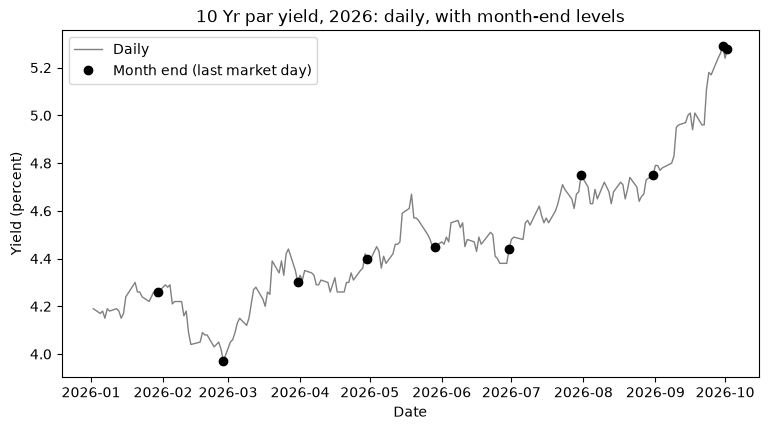

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(daily.loc["2026"].index, daily.loc["2026", "10 Yr"], color="grey", linewidth=1, label="Daily")
# each month-end dot sits on a real market date, so it lands on the daily line
ax.plot(month_end_2026.index, month_end_2026["10 Yr"], "o", color="black", label="Month end (last market day)")
ax.set_title("10 Yr par yield, 2026: daily, with month-end levels")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (percent)")
ax.legend()
plt.show()

* Every dot sits on the line, because every label is a date the line has. With `resample`'s labels, the January, February, and May dots would sit a day or two to the right of the line's last point for the month, on dates with no data.

## Excel Side by Side

Excel has every piece of today's work. Every line below was tested in Excel 16.0 build 20430, 2026-10-04, on the Treasury file in a sheet with its columns as Excel opens it: dates in A2:A2941, the 2 Yr in column I, the 5 Yr in K, the 10 Yr in M.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Calendar end of a month | `pd.date_range(..., freq="ME")` | `=EOMONTH(DATE(2026,5,15),0)` | 2026-05-31, a Sunday (`WEEKDAY(...,2)` returns 7) |
| Last market date of a month | `md.last_per_period(ten, "ME")` | `=MAXIFS(A2:A2941,A2:A2941,"<="&EOMONTH(DATE(2026,5,15),0))` | 2026-05-29 |
| Month-end level | the same row's value | `=XLOOKUP(that date,A2:A2941,M2:M2941)` | 4.45 |
| Friday that ends a date's week | `"W-FRI"` | `=A2+MOD(6-WEEKDAY(A2),7)` | 2025-04-16 gives 2025-04-18; a Saturday, 2025-04-19, gives 2025-04-25 |
| Last market date of a week | `md.last_per_period(ten, "W-FRI")` | `=MAXIFS(A2:A2941,A2:A2941,"<="&DATE(2025,4,18))` | 2025-04-17 |
| As-of value | `md.value_as_of(ten, "2026-09-07")` | `=XLOOKUP(DATE(2026,9,7),A2:A2941,M2:M2941,,-1)` | 4.78 |
| The date it comes from | the first item `value_as_of` returns | `=XLOOKUP(DATE(2026,9,7),A2:A2941,A2:A2941,,-1)` | 2026-09-04 |
| Before the first date | `ValueError` | `=XLOOKUP(DATE(2014,12,31),A2:A2941,M2:M2941,,-1)` | `#N/A` |
| Exact match on a holiday | `ten.loc["2026-09-07"]` raises `KeyError` | `=XLOOKUP(DATE(2026,9,7),A2:A2941,M2:M2941)` | `#N/A` |

**The month end, in three steps.** `EOMONTH(date, 0)` gives the calendar end of the date's month, which Course 1 used. `MAXIFS` then finds the largest date in column A that is on or before it: the month's last market date, the label `last_per_period` writes. `XLOOKUP` with an exact match fetches the 10 Yr on that date. Filled down a column with one starting date per month, the three formulas gave a date and a 10 Yr for all 142 months of the file, and every date and every value equalled `last_per_period`'s. A third column, `=(XLOOKUP(R1,...,M...)-XLOOKUP(R1,...,I...))*100`, gave the month-end 2s10s in bp, equal to Python's to the last digit.

**The week.** `WEEKDAY(A2)` counts Sunday as 1, so Friday is 6, and `MOD(6-WEEKDAY(A2),7)` is the number of days to the next Friday (0 on a Friday). Feed each Friday to the same `MAXIFS`: over all 614 weeks it gave `last_per_period`'s dates, 20 of them a Thursday.

**The as-of value** is `XLOOKUP` with match mode -1, "exact match or the next smaller item", which the docstring of `value_as_of` names. Course 1 used it for a month end. Before the first date there is no smaller item and Excel shows `#N/A`, the spreadsheet's version of the `ValueError`. Without the match mode, a holiday is not found and Excel shows `#N/A` too (day 3).

**A pivot table grouped by month.** Put the 2026 dates and the 10 Yr in a pivot table, put `date` in Rows and group it by Months only, then add `date` and the 10 Yr to Values, each summarised by Max. Max of date gave each month's last market date, the same 10 dates as `last_per_period`. Max of the 10 Yr is the month's **highest** yield, not its month-end level: it differed from the month-end level in 6 of 10 months. So take the dates from the pivot table and the values with `XLOOKUP`.

Q. Do the same thing in Python: for each month end of 2026, the largest file date on or before it, as `MAXIFS` does. Does it match `last_per_period`, and do the values match Excel's?

In [34]:
# MAXIFS in Python: the largest date on or before each calendar month end
calendar_2026 = pd.date_range("2026-01-31", periods=10, freq="ME")
maxifs_dates = [ten.index[ten.index <= end].max() for end in calendar_2026]
print(f"the same dates as last_per_period: {maxifs_dates == list(month_end.loc['2026'].index)}")

# the ten month-end 10 Yr values Excel returned with XLOOKUP, from the course's Excel check
excel_values = [4.26, 3.97, 4.3, 4.4, 4.45, 4.44, 4.75, 4.75, 5.29, 5.28]
print(f"the same values as Excel: {month_end.loc['2026'].tolist() == excel_values}")

the same dates as last_per_period: True
the same values as Excel: True


* The same dates and the same values. October's calendar end, 2026-10-31, is after the last date, and `MAXIFS` and `last_per_period` both land on 2026-10-02.

## Save the Day with Git

Today's Git step is `git stash`: a shelf for work you are not ready to commit. First, commit the day's work.

Q. Make the work folder a repository.

In [35]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [36]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course3_04_9wklzz3q and nowhere else


Q. Write the `.gitignore` before the first commit, as on day 1.

In [37]:
%%writefile .gitignore
# secrets, downloads, and databases never go into Git
.env
cache/
*.db
# folders Python and pytest make
__pycache__/
.pytest_cache/

Writing .gitignore


Q. Commit the module, the tests, and the `.gitignore`.

In [38]:
# choose the three files, commit, and show the history
!git -C "{work}" add .gitignore marketdata.py test_marketdata.py
!git -C "{work}" commit -q -m "Add last_per_period and value_as_of, with four tests" -m "Weekly and monthly series keep the date of the observation they hold; an as-of lookup stops before the first date."
!git -C "{work}" log --oneline

d26cd22 Add last_per_period and value_as_of, with four tests


Now an experiment. You wonder whether the first observation of each month would do instead of the last, and start trying it in `marketdata.py`.

Q. Add the unfinished experiment to the module.

In [39]:
%%writefile -a marketdata.py


# experiment, not finished: what if a month were represented by its first observation?
def month_first(series: pd.Series) -> pd.Series:
    """The first observation of each calendar month (an experiment)."""
    return series.resample("ME").first()

Appending to marketdata.py


In [40]:
# -uno leaves out files Git does not track, such as the data files
!git -C "{work}" status --short -uno

 M marketdata.py


* ` M marketdata.py`: changed, not committed.

A colleague asks for the month-end table now, from the tested module. The experiment is not ready to commit, and you do not want to lose it. **`git stash` puts the change on a shelf** and returns the file to its last commit.

Q. Stash the experiment with a message, and list the shelf.

In [41]:
# push puts the change on the shelf; list shows what is there; status shows a clean file
!git -C "{work}" stash push -m "experiment: first observation of each month"
!git -C "{work}" stash list
!git -C "{work}" status --short -uno

Saved working directory and index state On main: experiment: first observation of each month


stash@{0}: On main: experiment: first observation of each month


* `stash@{0}` is the experiment. The file is back to the commit, and `status` shows nothing to commit.

Q. Run the tests on the clean module, and give the colleague the table.

In [42]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.................                                                        [100%]
17 passed in 0.58s



In [43]:
# reload: the file on disk is the committed version again
importlib.reload(md)
print(f"month_first in the module: {hasattr(md, 'month_first')}")
md.last_per_period(ten, "ME").loc["2026-07":"2026-09"]

month_first in the module: False


date
2026-07-31    4.75
2026-08-31    4.75
2026-09-30    5.29
Name: 10 Yr, dtype: float64

Q. Back to the experiment. Take it off the shelf.

In [44]:
# pop puts the change back in the file and removes it from the shelf
!git -C "{work}" stash pop -q
!git -C "{work}" stash list
!git -C "{work}" diff --stat

 marketdata.py | 6 ++++++
 1 file changed, 6 insertions(+)


* The shelf is empty and the change is back: `diff --stat` counts the added lines.

The experiment answers its own question: `.first()` gives the start of the month, 4.79 percent for September 2026 against the month-end 5.29, and labels it with the month end. It is the wrong edge. Discard it.

In [45]:
# restore puts the file back to the last commit; the experiment is gone
!git -C "{work}" restore marketdata.py
!git -C "{work}" status --short -uno
!git -C "{work}" log --oneline

d26cd22 Add last_per_period and value_as_of, with four tests


* Nothing to commit and one commit in the log. `git stash drop` would have thrown away a stashed change without popping it; here the experiment came back first, so it could be read before it went.

## Bring It Home

Add today's two functions and four tests to your own `marketdata.py` and `test_marketdata.py` in `my_bondmath`. Open a PowerShell terminal in VS Code, with the course's `.venv` active.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code marketdata.py
code test_marketdata.py
```

**Step 2.** Paste the code of the two `%%writefile -a marketdata.py` cells of sections 4.2 and 4.5, without their first lines, at the end of `marketdata.py`, in that order. Paste the code of the `%%writefile -a test_marketdata.py` cell of section 4.5 at the end of `test_marketdata.py`. The tests read `treasury_par_yields.csv` from the folder the test file is in, so copy it there from the course repo's `data` folder if it is not there yet (for example with `Copy-Item`). Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_marketdata.py
```

```
.................                                                        [100%]
17 passed in 0.50s
```

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add marketdata.py test_marketdata.py
git commit -m "Add last_per_period and value_as_of, with four tests"
git log --oneline -3
```

**If a test fails**, compare your files with the cells. `test_month_end_label_is_observation_date` failing with `FileNotFoundError` means the Treasury file is not beside the test file.

**In Colab**, download `marketdata.py` and `test_marketdata.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say which observation stands for a week or a month (the last), and label it with the date it comes from.
* Explain why `resample(...).last()` labels a month 2026-05-31 when its value is from 2026-05-29, and why that matters in a join.
* Turn a daily series or table into weekly or monthly levels with `last_per_period`, including weeks that end on a Thursday.
* Tell `asfreq` from `last`: a grid of dates with holes, against the last observation of each period.
* Find the value as of any date with `value_as_of`, which returns the date it used and stops before the first observation.
* Do the same in Excel with `EOMONTH`, `MAXIFS`, and `XLOOKUP` with match mode -1, and read a pivot table's Max of date.
* Park unfinished work with `git stash`, and bring it back with `git stash pop`.

Tomorrow, day 5, finishes week 1: saving downloads in a cache, why ICE and Moody's series are never saved, and the course's daily dataset, built from the Treasury file and the synthetic spreads with every check of this week.

## Exercises

The exercises use the second set of series: the 5 Yr and the 30 Yr. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the Treasury file and defines `check`, a small function that marks your answers.

In [46]:
treasury = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
ten = treasury["10 Yr"]


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Make the weekly 5 Yr series with `md.last_per_period`, and keep the weeks whose last observation is in September 2026. Store their levels as a list of floats in **ex1_values**, and their labels as a list of `"YYYY-MM-DD"` strings in **ex1_labels**.

In [47]:
ex1_values = ...
ex1_labels = ...

In [48]:
check("Exercise 1 the weekly levels", ex1_values, [4.54, 4.78, 4.86, 4.98])
check("Exercise 1 the labels", ex1_labels, ['2026-09-04', '2026-09-11', '2026-09-18', '2026-09-25'])

Exercise 1 the weekly levels: not attempted yet
Exercise 1 the labels: not attempted yet


### Exercise 2

Q. 2026-01-19, 2026-05-25, and 2026-07-03 are weekdays with no row. Predict first, in a comment: which date will each as-of value come from? Then call `md.value_as_of(ten, day)` for each and store the three results, in that order, as a list of `(date, value)` tuples in **ex2_results**.

In [49]:
# your prediction:
ex2_results = ...

In [50]:
check("Exercise 2 the as-of values", ex2_results, [(pd.Timestamp("2026-01-16"), 4.24), (pd.Timestamp("2026-05-22"), 4.56), (pd.Timestamp("2026-07-02"), 4.49)])

Exercise 2 the as-of values: not attempted yet


### Exercise 3

Q. Add a function to your module. `month_end_table(curve, tenors)` returns the month-end levels of the chosen tenor columns of a curve, one row per calendar month, labelled by its last market date. Write the docstring first, use `last_per_period`, and raise `ValueError` naming any tenor that is not a column. Then add `test_month_end_table_labels_and_columns`: for `["5 Yr", "30 Yr"]`, the columns are those two, September 2026 is labelled 2026-09-30, 2026-05-29 is a label, and `["11 Yr"]` raises. Run pytest, reload the module, and store the 2026-09-30 row of `md.month_end_table(treasury, ["5 Yr", "30 Yr"])` as a list in **ex3_row**.

Write the function in the cell that starts with `%%writefile -a marketdata.py` and the test in the one that starts with `%%writefile -a test_marketdata.py`, and run each of those cells once.

In [51]:
%%writefile -a marketdata.py


# Exercise 3: write month_end_table(curve, tenors) below this line

Appending to marketdata.py


In [52]:
%%writefile -a test_marketdata.py


# Exercise 3: write test_month_end_table_labels_and_columns() below this line

Appending to test_marketdata.py


In [53]:
# run pytest, reload the module, then call your function
ex3_row = ...

In [54]:
check("Exercise 3 the September 2026 row", ex3_row, [5.09, 5.64])

Exercise 3 the September 2026 row: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that turns a daily yield series into month-end levels, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Month-end levels of a daily yield series: one value per calendar month.

    Units: unchanged (percent for a yield). Convention: each month's value is its month-end level, the
    observation on the last market day of the month. A month that ends on a weekend or a holiday takes the
    value of its last market day.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns one number per month, and contains one bug.

In [55]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def month_end_levels(series):
    """Month-end levels of a daily yield series: one value per calendar month.

    Units: unchanged (percent for a yield). Convention: each month's value is its month-end level, the
    observation on the last market day of the month. A month that ends on a weekend or a holiday takes the
    value of its last market day.
    """
    # group the daily rows into calendar months and keep one value from each
    return series.resample("ME").first()

Q. Before you run the next cell: the file's last September row is 2026-09-30 at 5.29 percent. What will the function show for September 2026?

In [56]:
month_end_levels(ten).loc["2026-07":"2026-09"]

date
2026-07-31    4.48
2026-08-31    4.70
2026-09-30    4.79
Freq: ME, Name: 10 Yr, dtype: float64

Q. Test the function against its docstring before you trust it.

In [57]:
# the test, written from the docstring before the code is trusted: September 2026 ended on 2026-09-30 at 5.29
levels = month_end_levels(ten)
assert levels.loc["2026-09-30"] == 5.29, f"September 2026 should be 5.29 percent, not {levels.loc['2026-09-30']}"
print("September 2026 is 5.29 percent, the month-end level")

AssertionError: September 2026 should be 5.29 percent, not 4.79

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store `month_end_levels(ten).loc["2026-09-30"]` in **ex4_september**, and the number of months the function returns, `len(month_end_levels(ten))`, in **ex4_months**.

In [58]:
# fix the function above and run the test again, then store the two answers
ex4_september = ...
ex4_months = ...

In [59]:
check("Exercise 4 September 2026", ex4_september, 5.29)
check("Exercise 4 the number of months", ex4_months, 142)

Exercise 4 September 2026: not attempted yet
Exercise 4 the number of months: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```